# Diplomatura en IA - UP 
### Practico N°2 - Jun26
### Alumno: Gonzalez Marta Elizabeth 
### Notebook 02 - EDA -

In [92]:
# Importacion de Librerias

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

pd.set_option('display.max_columns', None)

print("Librerías cargadas")

Librerías cargadas


#### Variables y Carga del Dataset

In [93]:
# Ubicacion del dataset excel:

PATH = "../data/processed/01_dataset_analizado.csv"

In [94]:
# Lectura del archivo generado en Notebook 01

df = pd.read_csv(PATH)


In [95]:
# Dimensiones

print(f"Cantidad de filas: {df.shape[0]}")
print(f"Cantidad de columnas: {df.shape[1]}")

Cantidad de filas: 50000
Cantidad de columnas: 27


In [96]:
# Primeras observaciones:

df.head()

,ID,gender,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,oral,dental caries,tartar,smoking
0,0,F,40,155,60,3.377083,0.043056,0.041667,0.041667,0.041667,4.750000,3.041667,3.916667,8.958333,3.416667,3.041667,5.250000,0.506250,0.041667,0.004861,0.750000,0.791667,1.125000,Y,0,Y,0
1,1,F,40,160,60,3.375000,0.005556,0.004167,0.041667,0.041667,4.958333,2.916667,5.416667,8.000000,4.791667,1.750000,5.291667,0.504861,0.041667,0.004167,0.916667,0.791667,0.750000,Y,0,Y,0
2,2,M,55,170,60,3.333333,0.005556,0.005556,0.041667,0.041667,5.750000,3.583333,3.708333,10.083333,7.583333,2.291667,6.291667,0.630556,0.041667,0.041667,0.875000,0.666667,0.916667,Y,0,N,1
3,3,M,40,165,70,3.666667,0.045139,0.045139,0.041667,0.041667,4.166667,2.500000,4.000000,13.416667,10.583333,1.875000,9.416667,0.588194,0.041667,0.041667,0.791667,1.083333,0.750000,Y,0,Y,0
4,4,F,40,155,60,3.583333,0.041667,0.041667,0.041667,0.041667,5.000000,3.083333,3.333333,7.666667,3.083333,2.583333,4.458333,0.503472,0.041667,0.004167,0.666667,0.583333,0.916667,Y,0,N,0


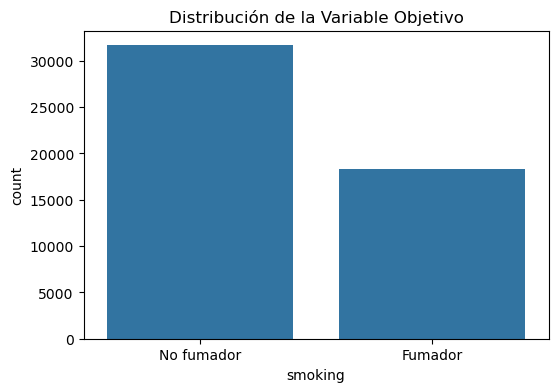

In [97]:
# Distribución de la variable objetivo

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='smoking'
)

plt.xticks([0,1],['No fumador','Fumador'])

plt.title('Distribución de la Variable Objetivo')

plt.show()

El conjunto de datos presenta aproximadamente un 63 % de personas no fumadoras y un 37 % de fumadoras. 
Aunque existe un desbalance moderado, ambas clases cuentan con una cantidad suficiente de observaciones, por lo que no fue necesario aplicar técnicas de balanceo como SMOTE.

In [98]:
# Porcentajes

round(
    df['smoking'].value_counts(normalize=True)*100,
    2
)

smoking
0    63.34
1    36.66
Name: proportion, dtype: float64

In [99]:
# Distribución de variables numéricas

numericas = df.select_dtypes(
    include=['int64','float64']
).columns

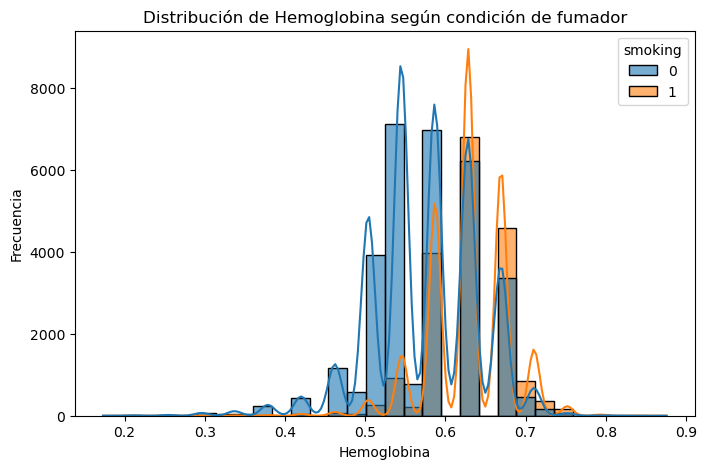

In [100]:
# Histograma

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="hemoglobin",
    hue="smoking",
    kde=True,
    bins=30,
    alpha=0.6
)

plt.title("Distribución de Hemoglobina según condición de fumador")
plt.xlabel("Hemoglobina")
plt.ylabel("Frecuencia")

plt.show()  



Se observa que la distribución de hemoglobina presenta un desplazamiento hacia valores mayores en el grupo de fumadores. 
Este comportamiento sugiere una asociación positiva entre el hábito de fumar y los niveles de hemoglobina. 

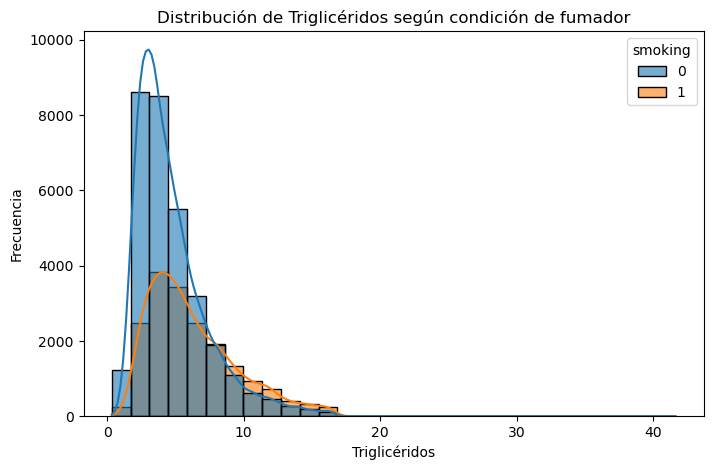

In [101]:
# Histograma

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="triglyceride",
    hue="smoking",
    kde=True,
    bins=30,
    alpha=0.6
)

plt.title("Distribución de Triglicéridos según condición de fumador")
plt.xlabel("Triglicéridos")
plt.ylabel("Frecuencia")

plt.show()

La distribución de los niveles de triglicéridos muestra una mayor concentración de valores elevados en los individuos fumadores. 
Esto indica una posible relación entre el tabaquismo y alteraciones en el metabolismo lipídico, lo que convierte a esta variable en una de las más 
relevantes para la predicción del hábito de fumar.

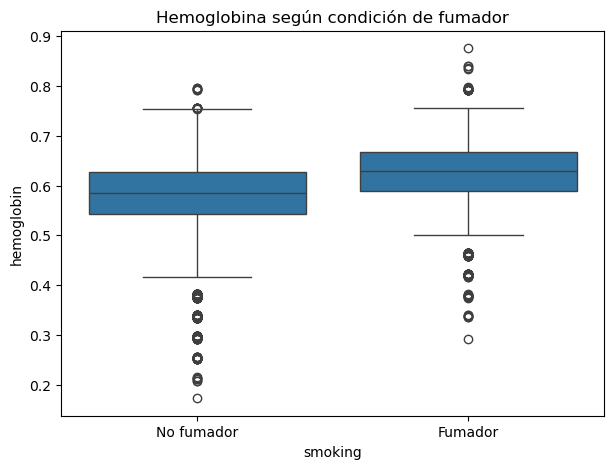

In [102]:
# Boxplots para detección visual de outliers

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="smoking",
    y="hemoglobin"
)

plt.xticks([0,1],["No fumador","Fumador"])

plt.title("Hemoglobina según condición de fumador")

plt.show()

El boxplot muestra que la mediana de hemoglobina es superior en el grupo de fumadores. 
Ademas, se observa un desplazamiento general de la distribución hacia valores más elevados, lo que confirma la asociación detectada durante el análisis exploratorio.

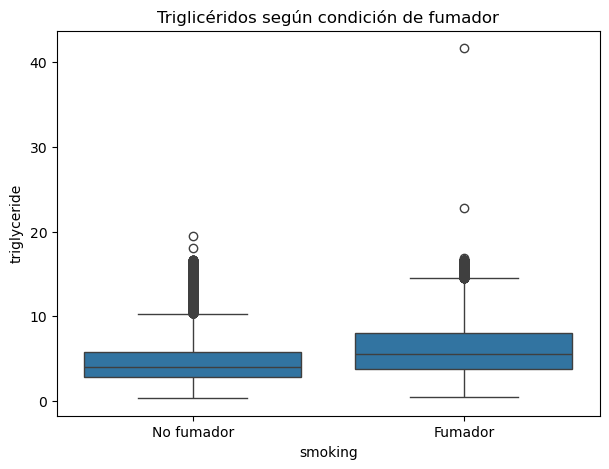

In [103]:
# Boxplot

plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x="smoking",
    y="triglyceride"
)

plt.xticks([0,1],["No fumador","Fumador"])

plt.title("Triglicéridos según condición de fumador")

plt.show()

La mediana de triglicéridos es superior en fumadores y se observa una mayor presencia de valores extremos. Estos seran tratados posteriormente durante el preprocesamiento.

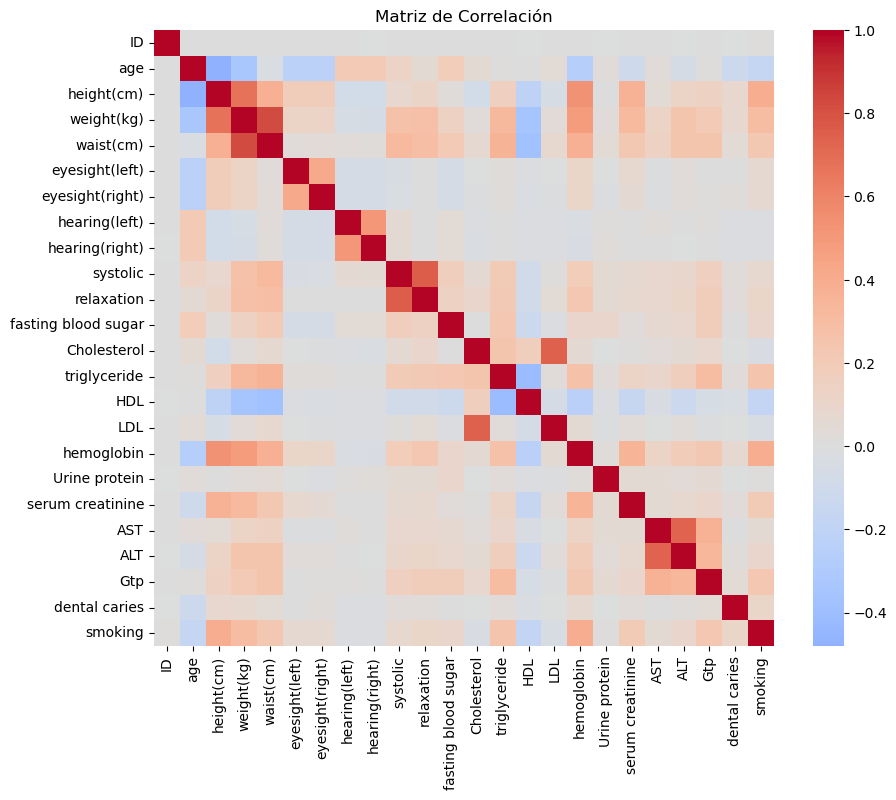

In [104]:
# Correlacion Global

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title("Matriz de Correlación")
plt.show()

In [105]:
# Correlacion con smoking

corr_smoking = (
    corr['smoking']
    .sort_values(ascending=False)
)

corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

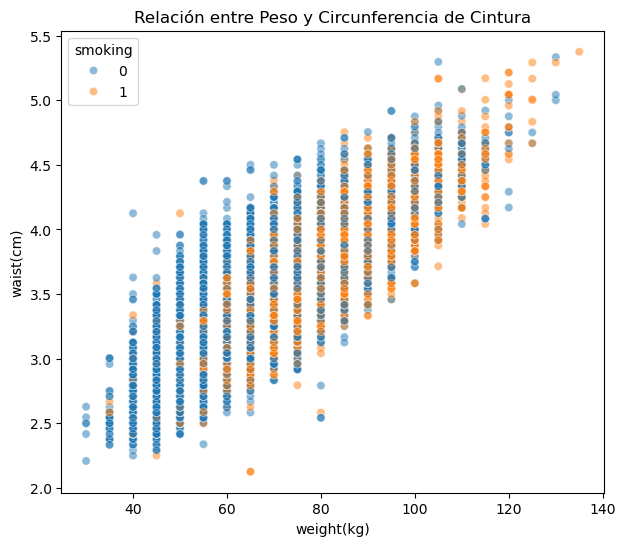

In [106]:
# Scatterplot Peso y Circunferencia de Cintura

plt.figure(figsize=(7,6))

sns.scatterplot(
    data=df,
    x='weight(kg)',
    y='waist(cm)',
    hue='smoking',
    alpha=0.5
)

plt.title('Relación entre Peso y Circunferencia de Cintura')

plt.show()

Se observa una relación positiva entre el peso corporal y la circunferencia de cintura. 
Esta asociación respalda la incorporación de variables derivadas como el Índice de Masa Corporal (BMI) y la Relación Cintura-Altura (WHR), utilizadas posteriormente durante el proceso de ingeniería de características.

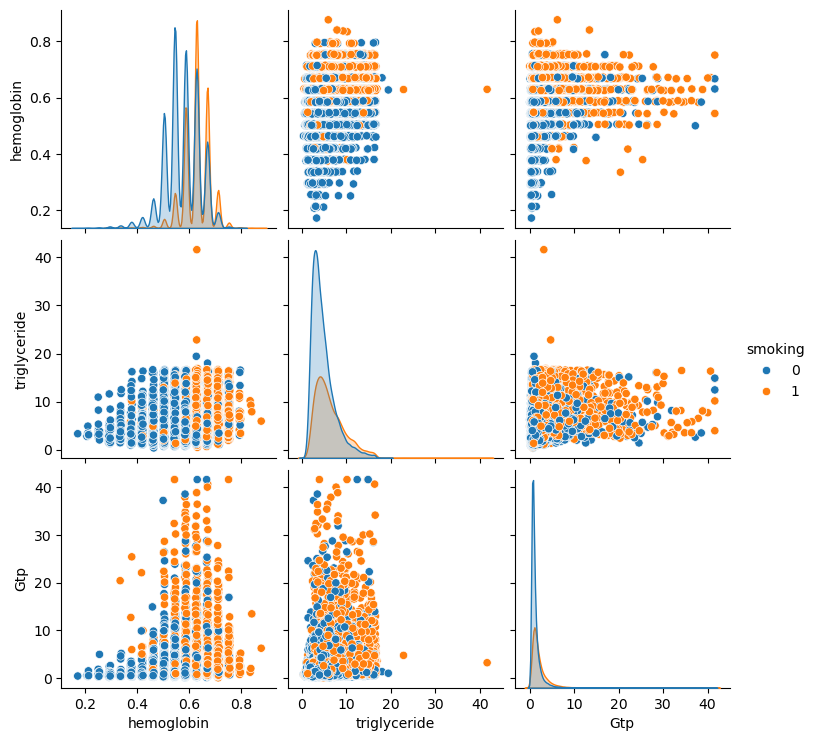

In [107]:
# Pairplot de variables: Hemoglobina, Trigliceridos, Gtp y Smoking

variables = [
    "hemoglobin",
    "triglyceride",
    "Gtp",
    "smoking"
]

sns.pairplot(
    df[variables],
    hue="smoking",
    diag_kind="kde"
)

plt.show()

El pairplot permite analizar simultáneamente las distribuciones individuales y las relaciones entre las variables más relevantes. 
Se observa una separación parcial entre fumadores y no fumadores, especialmente en hemoglobina y triglicéridos, lo que confirma su capacidad discriminante.

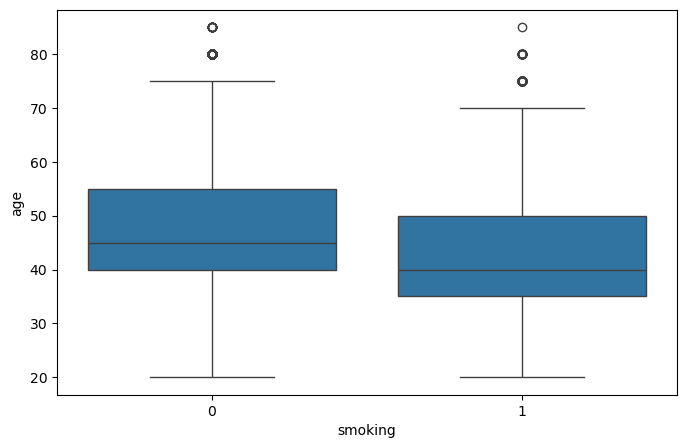

In [108]:
# Variables numéricas vs Smoking
# Edad

plt.figure(figsize=(8,5))

sns.boxplot(
    x='smoking',
    y='age',
    data=df
)

plt.show()

Se observa que los fumadores estan en el rango de los 37 a 50 años. Y los no fumadores, entre los 40 y 55 años.

In [109]:
# Variables categóricas vs Smoking
# Genero:

pd.crosstab(
    df['gender'],
    df['smoking'],
    normalize='index'
)*100

smoking,0,1
gender,,
F,95.723540,4.276460
M,44.783539,55.216461


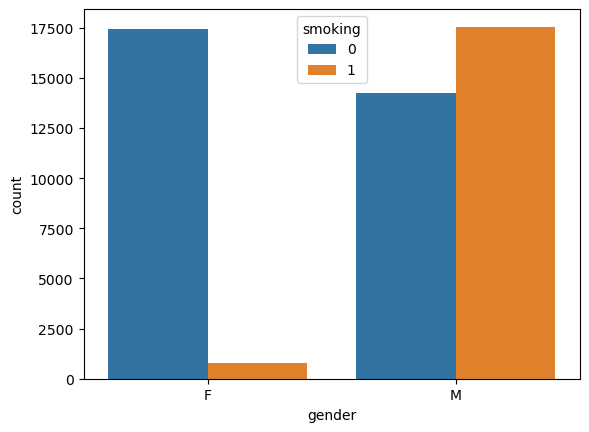

In [110]:
sns.countplot(
    x='gender',
    hue='smoking',
    data=df
)

plt.show()

El grafico muestra que los masculinos tienen mayor habito de fumar.

In [111]:
# Oral

pd.crosstab(
    df['oral'],
    df['smoking'],
    normalize='index'
)*100

smoking,0,1
oral,,
Y,63.342,36.658


In [112]:
from sklearn.feature_selection import mutual_info_classif

# Variables predictoras
X = df.drop('smoking', axis=1)

# Variable objetivo
y = df['smoking']

# Transformación temporal para Mutual Information
X_mi = pd.get_dummies(
    X,
    drop_first=True
)

# Cálculo de importancia
mi = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

In [113]:
mi_df = pd.DataFrame({
    'Variable': X_mi.columns,
    'Importancia': mi
})

mi_df = mi_df.sort_values(
    by='Importancia',
    ascending=False
)

mi_df.head(15)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [114]:
X = df.drop('smoking', axis=1)
y = df['smoking']

print(X.shape)
print(y.shape)

(50000, 26)
(50000,)


In [115]:
X_mi = pd.get_dummies(
    X,
    drop_first=True
)

print(X_mi.shape)

(50000, 25)


In [116]:
mi = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

print(len(mi))

25


In [117]:
mi_df = pd.DataFrame({
    'Variable': X_mi.columns,
    'Importancia': mi
})

mi_df.sort_values(
    'Importancia',
    ascending=False
).head(15)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [118]:
mi_df.head(15)

,Variable,Importancia
0,ID,0.002630
1,age,0.016077
2,height(cm),0.102480
3,weight(kg),0.056375
4,waist(cm),0.029524
5,eyesight(left),0.007032
6,eyesight(right),0.005601
7,hearing(left),0.005179
8,hearing(right),0.004423
9,systolic,0.005758


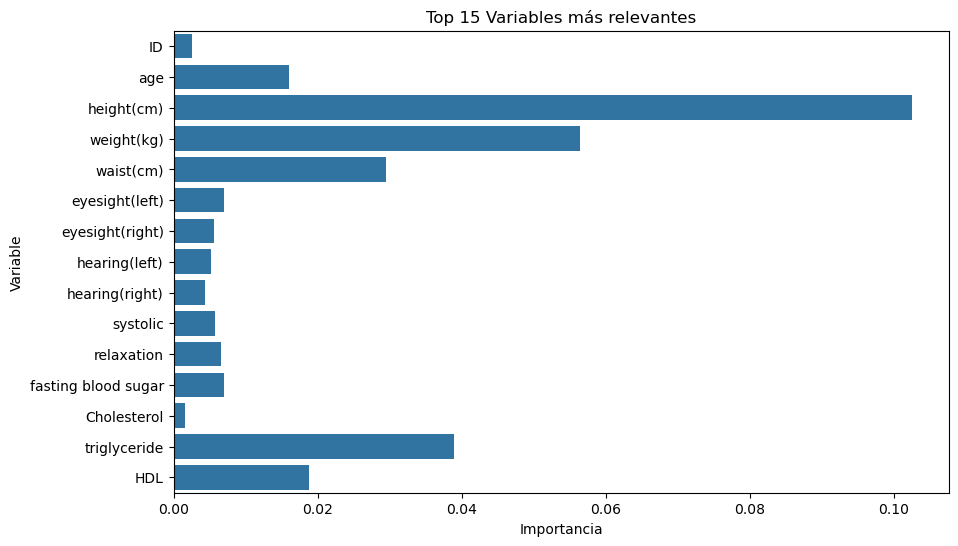

In [119]:
# Grafico

plt.figure(figsize=(10,6))

sns.barplot(
    data=mi_df.head(15),
    x='Importancia',
    y='Variable'
)

plt.title("Top 15 Variables más relevantes")

plt.show()

El análisis de Mutual Information permitió identificar las variables con mayor aporte predictivo considerando relaciones tanto lineales como no lineales. Los resultados justifican el uso de modelos basados en árboles, como Random Forest, capaces de capturar este tipo de patrones complejos.

In [120]:
mi_df.head(20)

,Variable,Importancia
0,ID,0.002630
1,age,0.016077
2,height(cm),0.102480
3,weight(kg),0.056375
4,waist(cm),0.029524
5,eyesight(left),0.007032
6,eyesight(right),0.005601
7,hearing(left),0.005179
8,hearing(right),0.004423
9,systolic,0.005758


In [121]:
corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

In [122]:
mi_df.sort_values(
    by='Importancia',
    ascending=False
).head(20)

,Variable,Importancia
23,gender_M,0.162169
16,hemoglobin,0.102674
2,height(cm),0.102480
21,Gtp,0.074168
3,weight(kg),0.056375
18,serum creatinine,0.044695
13,triglyceride,0.038877
4,waist(cm),0.029524
20,ALT,0.024723
14,HDL,0.018835


In [123]:
corr_smoking = (
    corr['smoking']
    .sort_values(ascending=False)
)

corr_smoking

smoking                1.000000
height(cm)             0.396284
hemoglobin             0.395972
weight(kg)             0.301405
triglyceride           0.251116
Gtp                    0.235980
waist(cm)              0.224623
serum creatinine       0.198660
relaxation             0.108155
dental caries          0.103757
fasting blood sugar    0.098124
ALT                    0.094137
systolic               0.073225
eyesight(right)        0.068783
eyesight(left)         0.066099
AST                    0.057348
Urine protein          0.015284
ID                     0.012211
hearing(right)        -0.017727
hearing(left)         -0.021871
Cholesterol           -0.030030
LDL                   -0.045706
age                   -0.163722
HDL                   -0.176993
Name: smoking, dtype: float64

In [124]:
[col for col in X_mi.columns if 'gender' in col]

['gender_M']

In [125]:
# Exportación para Notebook 03

df.to_csv(
    "../data/processed/02_dataset_eda.csv",
    index=False
)

print("Archivo exportado correctamente")

Archivo exportado correctamente
